# Práctica: Análisis de Datos de Diabetes y Redes Neuronales

Este notebook te guiará a través del proceso de carga de datos, ingeniería de características y construcción de modelos de Deep Learning con Keras.

### 1. Carga y Análisis Inicial de Datos

**Instrucciones:**
1. Importa las librerías necesarias (pandas, numpy, seaborn, matplotlib, etc.).
2. Carga el archivo de datos en un DataFrame de Pandas llamado `diabetes_data`.
3. Analiza los datos iniciales para comprender su estructura y características principales (usa `.head()`, `.info()`).

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cargar dataframe
df = pd.read_csv('/content/drive/MyDrive/Datasets/diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### 2. Ingeniería de Características (Feature Engineering)

**Instrucciones:**
Añade una nueva característica al DataFrame:

* Calcula una nueva columna llamada **"Glucose_Insulin_Ratio"** (relación glucosa/insulina).
* Esta se define como el cociente entre las columnas `Glucose` y `Insulin` (maneja casos donde Insulin sea 0 para evitar divisiones por cero, por ejemplo, asignando un valor alto o NaN).

In [ ]:
#df["Glucose_Insulin_Ratio"] = df["Glucose"] / df["Insulin"]

#df.head()

In [ ]:
# Tu código aquí


### 3. Preguntas sobre los Datos

Responde a las siguientes preguntas mediante código:
1.  ¿Cuántas filas y columnas tiene el DataFrame?
2.  ¿Faltan datos en el conjunto? En caso afirmativo, identifica las columnas afectadas.

In [ ]:
df.info()
# Tiene un total de 9 columnas y 768 filas

print("\n ============== \n")

df.isnull().sum()

# No, no tiene valores nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB




,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


### 4. Estadísticas Descriptivas y Visualización

**Instrucciones:**
1.  **Estadísticas:** Genera y revisa las estadísticas descriptivas del conjunto de datos para entender la distribución de las características (usa `.describe()`).
2.  **Visualización:** Visualiza la distribución de las características utilizando gráficos (histogramas, boxplots) para identificar patrones o tendencias.

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


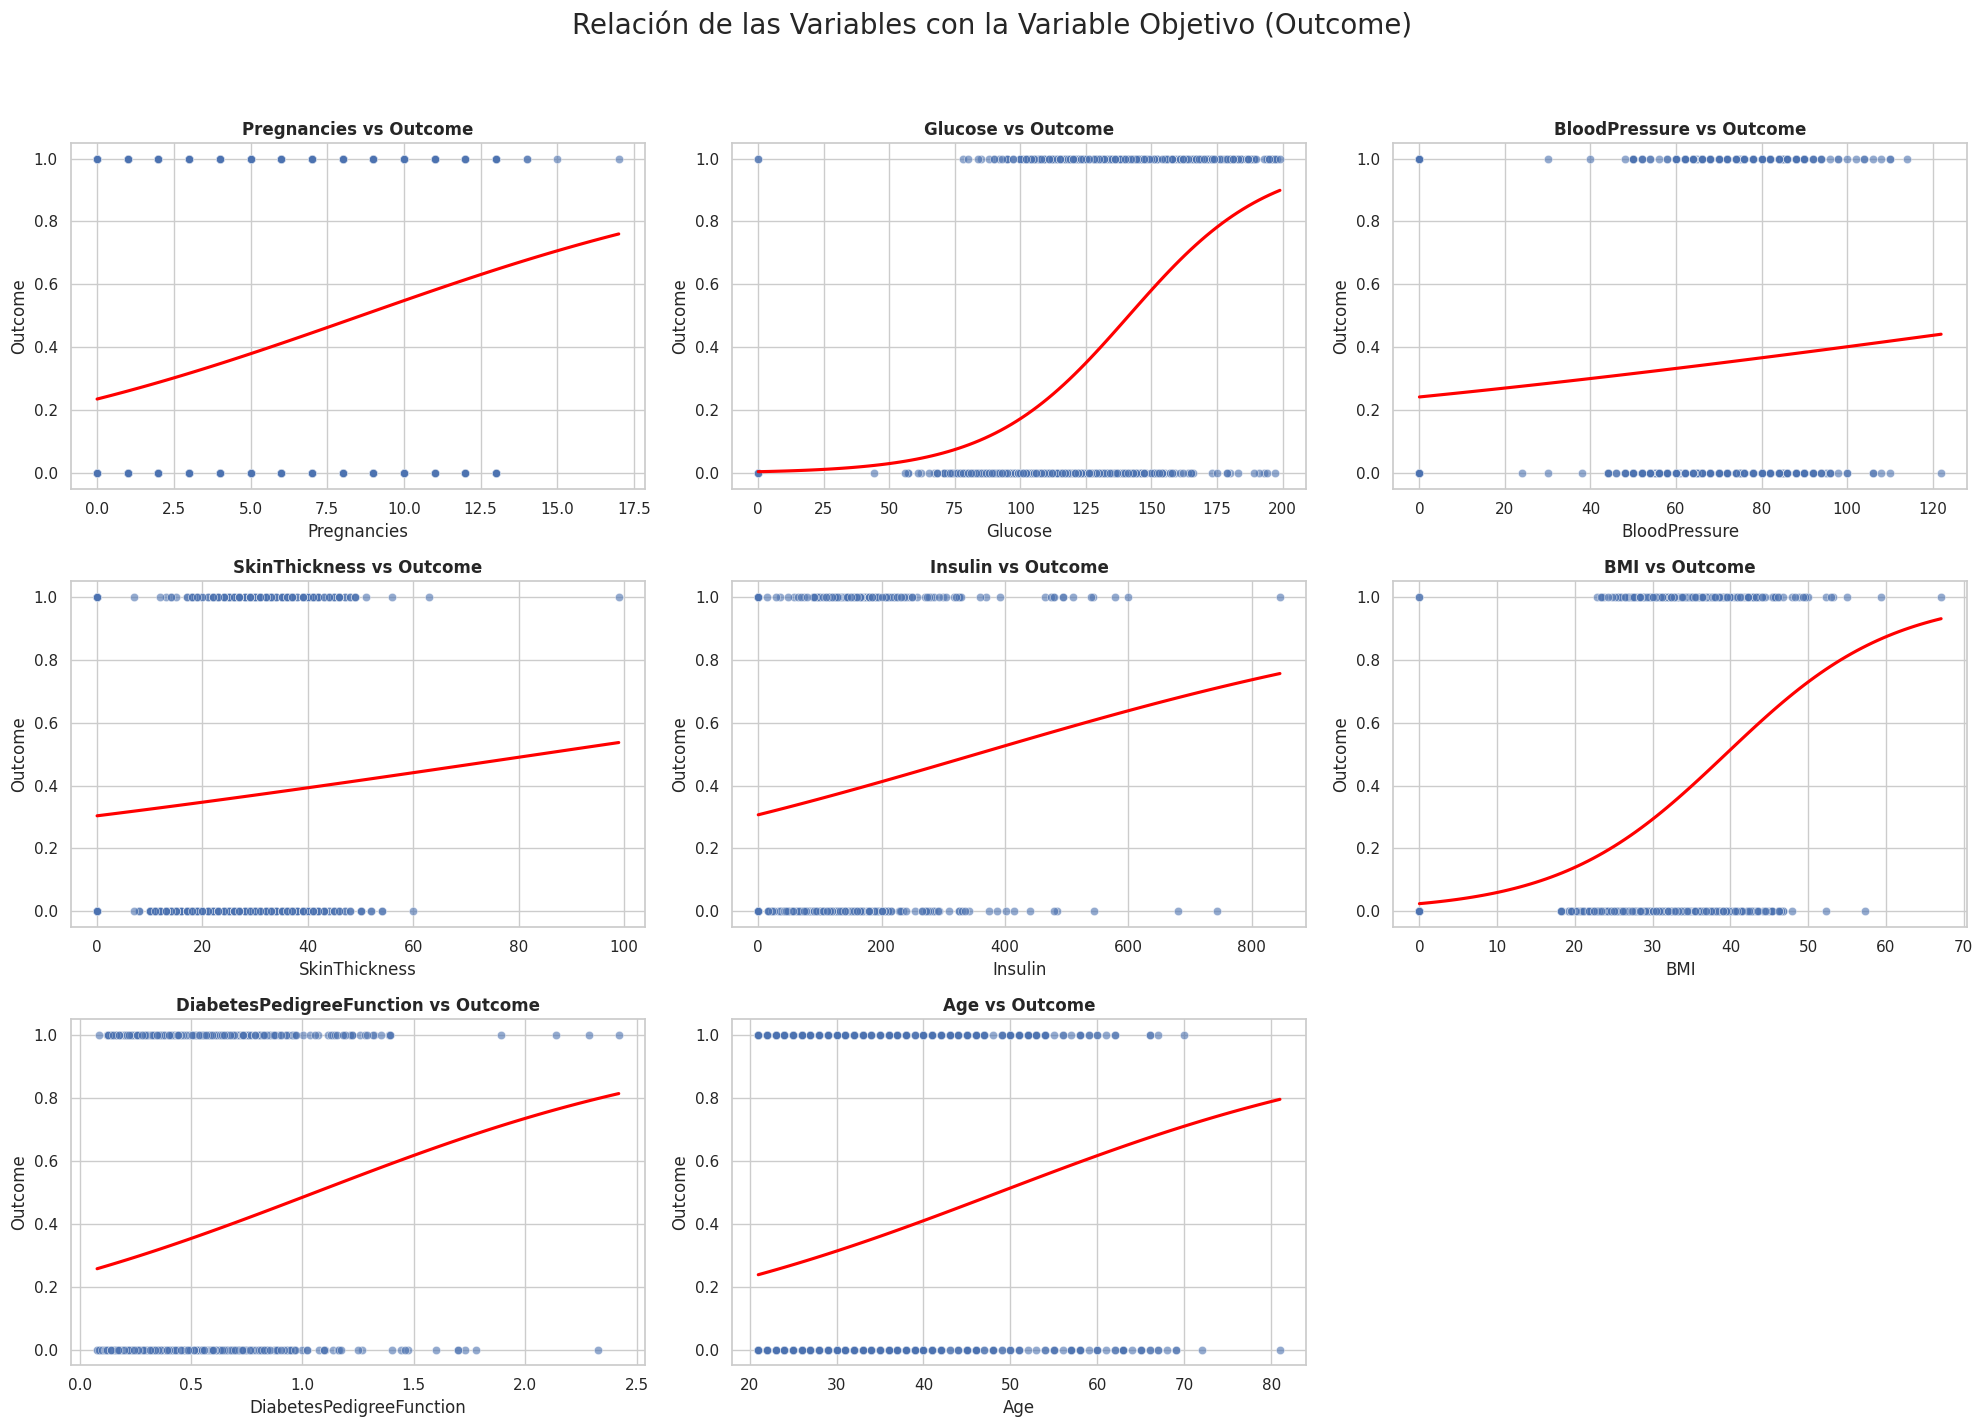

In [ ]:
# Configuración de estilo visual
sns.set(style="whitegrid")

# 1. Definir las variables (Columnas del dataset de Diabetes)
features = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

target = 'Outcome'

# 2. Configurar el tamaño de la figura y la cuadrícula (3 filas x 3 columnas = 9 gráficos)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 15))
fig.suptitle('Relación de las Variables con la Variable Objetivo (Outcome)', fontsize=20)

# Aplanar el array de ejes para iterar fácilmente
axes = axes.flatten()

# 3. Generar los gráficos
for i, col in enumerate(features):
    # Crear el Scatter Plot
    # Nota: Como 'Outcome' es 0 o 1, los puntos se alinearán en dos filas horizontales.
    sns.scatterplot(data=df, x=col, y=target, ax=axes[i], alpha=0.6, color='b')

    # Añadir línea de regresión logística
    # Usamos logistic=True en regplot para ver mejor la probabilidad (curva sigmoide) en lugar de una recta
    sns.regplot(data=df, x=col, y=target, ax=axes[i], scatter=False, color='red', logistic=True, ci=None)

    # Títulos y etiquetas
    axes[i].set_title(f'{col} vs {target}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)

# 4. Ocultar los ejes sobrantes (en este caso, el gráfico número 9)
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

# Ajustar el espacio entre gráficos
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Mostrar
plt.show()

### 5. Construcción de una Red Neuronal Inicial

**Instrucciones:**
Usa la biblioteca **Keras** para crear una red neuronal con las siguientes especificaciones:

* **Estructura:** Una capa oculta con 10 nodos y función de activación ReLU.
* **Salida:** 1 nodo (para clasificación binaria, con activación sigmoid).
* **Optimizador:** ADAM.
* **Función de pérdida:** Binary Crossentropy.

*Recuerda separar primero los datos en predictores (X) y objetivo (y).*

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Input
import tensorflow as tf

# Establecer la semilla para la reproducibilidad
tf.random.set_seed(42)

# X - Datos, Y - Variable Objetivo (Target)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 2. Dividir y Escalar los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Construir y compilar el modelo
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(10, activation='relu'),
    Dense(1, activation='sigmoid') # Capa de salida para clasificación binaria
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 4. Entrenar el modelo
history_without_normalize = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=10,
    verbose=0,
    validation_split=0.1, # 10% del entrenamiento para validación
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)],
)

# 5. Evaluar el modelo
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

### 6. Normalización de Datos

**Instrucciones:**
1.  Normaliza las variables predictoras restando la media y dividiendo entre la desviación estándar.
2.  Usa este conjunto normalizado para construir y entrenar una nueva red neuronal (misma arquitectura que arriba).

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
input_shape = X_train_scaled.shape[1] # 8 características

# 3. Construir y compilar el modelo
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(10, activation='relu'),
    Dense(1, activation='sigmoid') # Capa de salida para clasificación binaria
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 4. Entrenar el modelo
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=10,
    verbose=0,
    validation_split=0.1, # 10% del entrenamiento para validación
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)],
)

# 5. Evaluar el modelo
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

### 7. Mejoras en la Red Neuronal y Gráficos

**Instrucciones:**
1.  **Mejora:** Aumenta el número de capas en la red neuronal o nodos y ajusta su arquitectura.
2.  **Entrenamiento:** Entrena el modelo guardando el historial (`history = model.fit(...)`).
3.  **Gráficos:** Dibuja gráficos que muestren cómo evoluciona la pérdida (loss) durante el entrenamiento.

In [ ]:
from tensorflow.keras.layers import BatchNormalization, Dropout

model = Sequential([
    Input(shape=(input_shape,)),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')  # Clasificación binaria
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_mejorado = model.fit(
    X_train_scaled,
    y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - accuracy: 0.6482 - loss: 0.6833 - val_accuracy: 0.6774 - val_loss: 0.6244
Epoch 2/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7241 - loss: 0.5476 - val_accuracy: 0.7419 - val_loss: 0.5760
Epoch 3/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7600 - loss: 0.5128 - val_accuracy: 0.7581 - val_loss: 0.5408
Epoch 4/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7562 - loss: 0.4915 - val_accuracy: 0.7258 - val_loss: 0.5250
Epoch 5/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7906 - loss: 0.4676 - val_accuracy: 0.7258 - val_loss: 0.5186
Epoch 6/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7827 - loss: 0.4611 - val_accuracy: 0.7742 - val_loss: 0.5044
Epoch 7/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7863 - loss: 0.4601 - val_accuracy: 0.7742 - val_loss: 0.4968
Epoch 8/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7992 - loss: 0.4426 - val_accuracy: 0.7581 - 

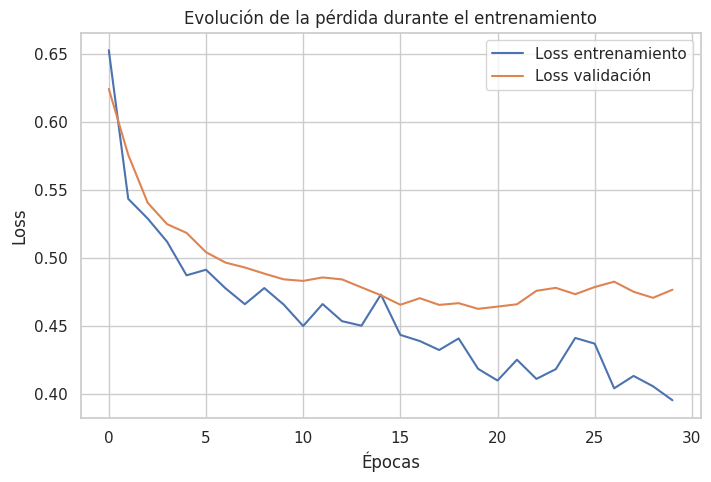

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_mejorado.history['loss'], label='Loss entrenamiento')
plt.plot(history_mejorado.history['val_loss'], label='Loss validación')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Evolución de la pérdida durante el entrenamiento')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Loss test: {loss:.4f}")
print(f"Accuracy test: {accuracy:.4f}")

Loss test: 0.5070
Accuracy test: 0.7662


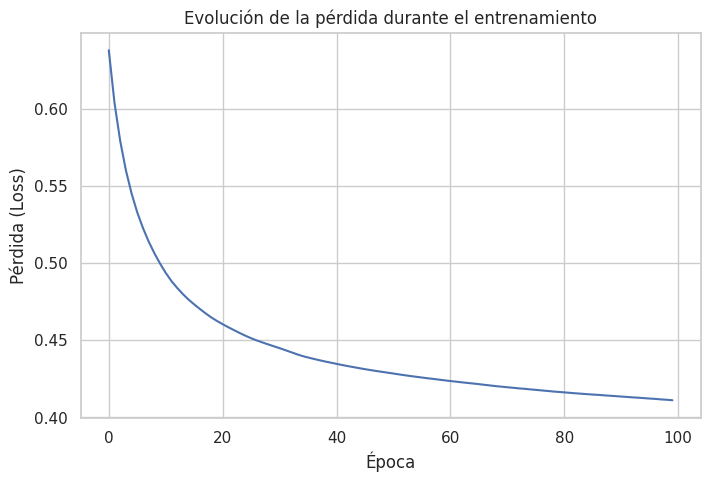

In [ ]:
# Extraer valores de pérdida
loss = history.history["loss"]

# Estilo visual
sns.set(style="whitegrid")

# Gráfico
plt.figure(figsize=(8,5))
plt.plot(loss)
plt.xlabel("Época")
plt.ylabel("Pérdida (Loss)")
plt.title("Evolución de la pérdida durante el entrenamiento")
plt.show()

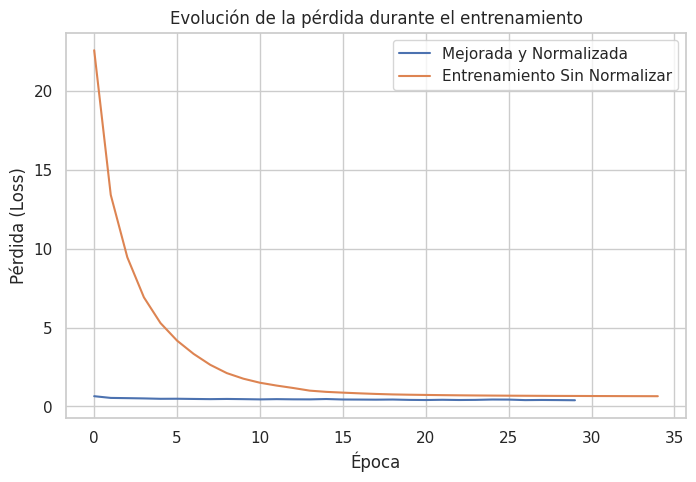

In [ ]:
# Extraer valores de pérdida
loss = history_mejorado.history["loss"]

# Estilo visual
sns.set(style="whitegrid")

# Gráfico
plt.figure(figsize=(8,5))
plt.plot(loss, label="Mejorada y Normalizada")
plt.plot(history_without_normalize.history["loss"], label='Entrenamiento Sin Normalizar')
plt.legend()
plt.xlabel("Época")
plt.ylabel("Pérdida (Loss)")
plt.title("Evolución de la pérdida durante el entrenamiento")
plt.show()